# 04 — Classification (Apple M1 Purchase Prediction)

**Input:** `data/processed/processed_m1_data.csv` (features + m1_purchase binary)  
**Output:** `models/m1_classifier.pkl`

Predict whether a customer will buy an Apple M1 product (1 = Yes, 0 = No) using RandomForest.


# Imports

In [9]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split

warnings.filterwarnings('ignore')

PLOT_DIR = Path('../plots/classification')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Read Data

In [10]:
# Load processed M1 data
df = pd.read_csv('../data/processed/processed_m1_data.csv')

# Separate features and target
if 'm1_purchase' not in df.columns:
    raise ValueError('m1_purchase column not found in processed_m1_data.csv')

X = df.drop(columns=['m1_purchase'])
y = df['m1_purchase']

print(f'Features shape: {X.shape} | Target shape: {y.shape}')
print(f'Target distribution:\n{y.value_counts()}')
print(f'  0 (No): {(y == 0).sum()}, 1 (Yes): {(y == 1).sum()}')


Features shape: (133, 21) | Target shape: (133,)
Target distribution:
m1_purchase
1    88
0    45
Name: count, dtype: int64
  0 (No): 45, 1 (Yes): 88


## Train-Test Split

In [11]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (106, 21) | Test: (27, 21)


# Random-Forest

In [12]:
# Train Random Forest classifier for M1 purchase prediction
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
clf.fit(X_train, y_train)

cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1 Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual scores: {cv_scores.round(4)}')

5-Fold CV F1 Score: 0.7643 ± 0.0526
Individual scores: [0.75   0.8485 0.6875 0.75   0.7857]


# Predict

In [13]:
# Evaluate on test set
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy:.4f}')
print('\nClassification Report (0=No, 1=Yes):')
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

Test Accuracy: 0.7037

Classification Report (0=No, 1=Yes):
              precision    recall  f1-score   support

      No (0)       0.55      0.67      0.60         9
     Yes (1)       0.81      0.72      0.76        18

    accuracy                           0.70        27
   macro avg       0.68      0.69      0.68        27
weighted avg       0.72      0.70      0.71        27



# Confusion matrix

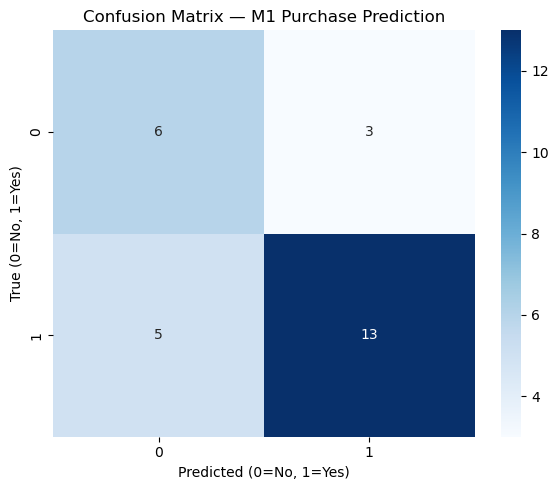

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted (0=No, 1=Yes)')
plt.ylabel('True (0=No, 1=Yes)')
plt.title('Confusion Matrix — M1 Purchase Prediction')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

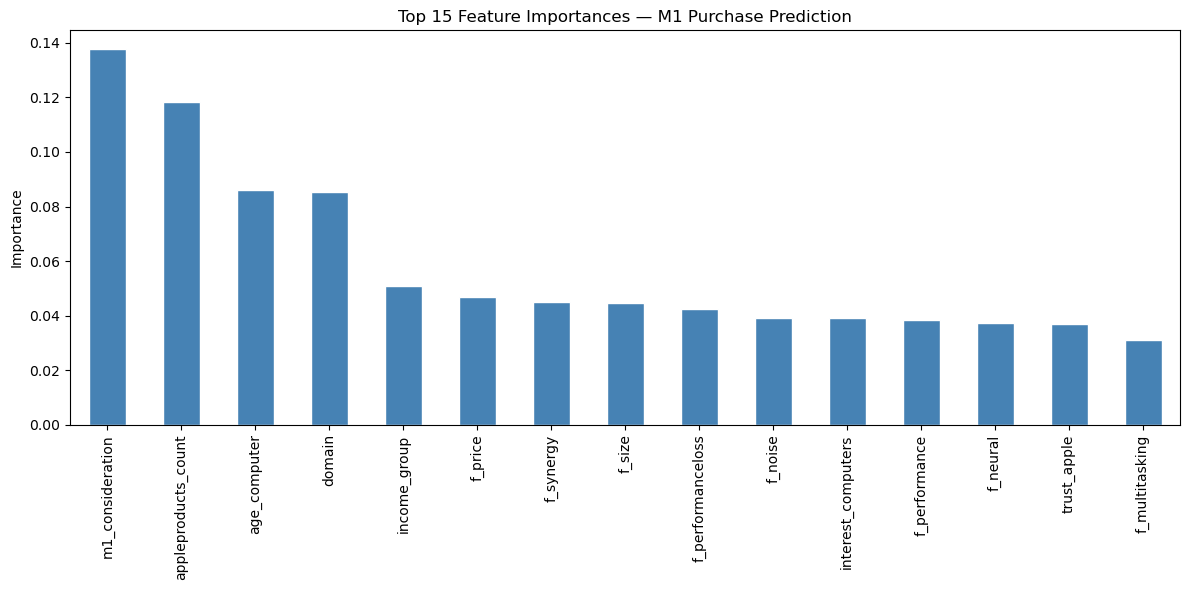


Top 15 Feature Importances:
m1_consideration       0.137731
appleproducts_count    0.118409
age_computer           0.085880
domain                 0.085478
income_group           0.050681
f_price                0.046934
f_synergy              0.044952
f_size                 0.044778
f_performanceloss      0.042374
f_noise                0.039071
interest_computers     0.038953
f_performance          0.038201
f_neural               0.037452
trust_apple            0.036902
f_multitasking         0.030900
dtype: float64


In [15]:
# Feature importance for M1 purchase prediction
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
importances.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Feature Importances — M1 Purchase Prediction')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'feature_importances_m1.png', dpi=150)
plt.show()
print('\nTop 15 Feature Importances:')
print(importances.head(15))

# Save and Test Saved Model

In [18]:
# Save model
with open('../models/m1_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

print('✓ Saved m1_classifier.pkl')


✓ Saved m1_classifier.pkl


# Test Model

In [19]:
# Load saved model and test
with open('../models/m1_classifier.pkl', 'rb') as f:
    loaded_clf = pickle.load(f)

loaded_y_pred = loaded_clf.predict(X_test)
print(f'\nLoaded Model Test Accuracy: {accuracy_score(y_test, loaded_y_pred):.4f}')
print('\nLoaded Model Classification Report:')
print(classification_report(y_test, loaded_y_pred, target_names=['No (0)', 'Yes (1)']))

sample_preds = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True).head(10),
    'Predicted': pd.Series(loaded_y_pred).head(10),
    'Match': (y_test.reset_index(drop=True).head(10).values == loaded_y_pred[:10])
})
print('\nSample Predictions (first 10 rows):')
print(sample_preds)



Loaded Model Test Accuracy: 0.7037

Loaded Model Classification Report:
              precision    recall  f1-score   support

      No (0)       0.55      0.67      0.60         9
     Yes (1)       0.81      0.72      0.76        18

    accuracy                           0.70        27
   macro avg       0.68      0.69      0.68        27
weighted avg       0.72      0.70      0.71        27


Sample Predictions (first 10 rows):
   Actual  Predicted  Match
0       1          1   True
1       0          0   True
2       0          0   True
3       1          1   True
4       1          1   True
5       1          1   True
6       0          1  False
7       1          1   True
8       0          0   True
9       1          1   True
